In [316]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [317]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('/content/drive/MyDrive/heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [318]:
df.shape

(918, 12)

In [319]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [321]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [322]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [323]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [324]:
df.duplicated().sum()

np.int64(0)

In [325]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


<Axes: xlabel='HeartDisease', ylabel='count'>

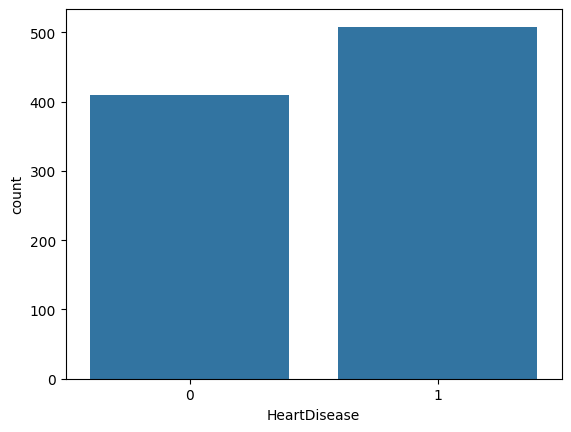

In [326]:
sns.countplot(x='HeartDisease',data=df)

<Axes: xlabel='Sex', ylabel='count'>

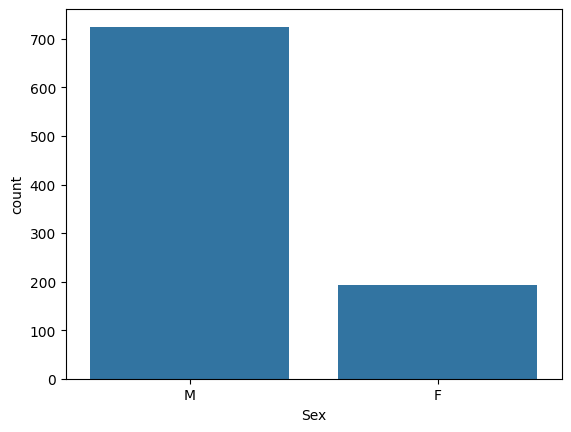

In [327]:
sns.countplot(x='Sex',data=df)

<Axes: xlabel='Sex', ylabel='count'>

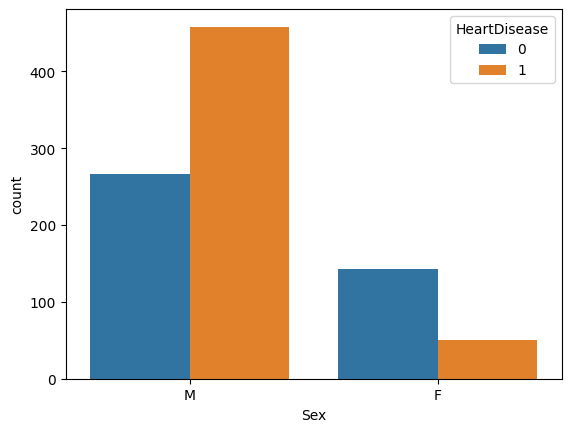

In [328]:
sns.countplot(x='Sex',hue='HeartDisease',data=df)

<Axes: xlabel='ChestPainType', ylabel='count'>

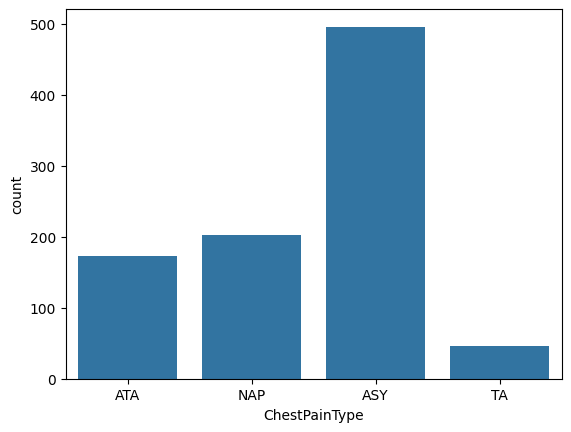

In [329]:
sns.countplot(x='ChestPainType',data=df)

<Axes: xlabel='ChestPainType', ylabel='count'>

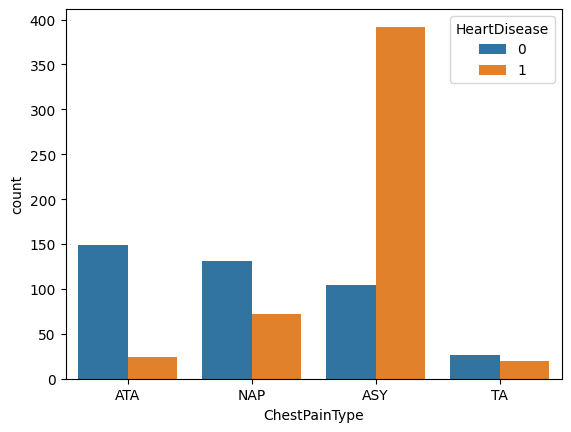

In [330]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

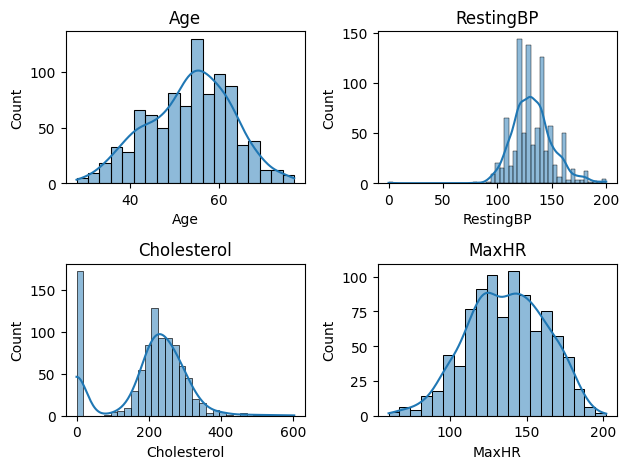

In [331]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
  plt.title(var)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [332]:
df_cleaned=df.copy()

In [333]:
df_cleaned.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [334]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [335]:
ch_mean=df.loc[df['Cholesterol'] !=0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [336]:
df_cleaned['Cholesterol']=df_cleaned['Cholesterol'].replace(0,ch_mean)
df_cleaned['Cholesterol']=df_cleaned['Cholesterol'].round(2)
df_cleaned['Cholesterol']

,Cholesterol
0,289.0
1,180.0
2,283.0
3,214.0
4,195.0
...,...
913,264.0
914,193.0
915,131.0
916,236.0


In [337]:
df_cleanedbp=df.loc[df_cleaned['RestingBP']!=0,'RestingBP'].mean()
df_cleaned['RestingBP']=df_cleaned['RestingBP'].replace(0,df_cleanedbp)
df_cleaned['RestingBP']=df_cleaned['RestingBP'].round(2)
df_cleaned['RestingBP']

,RestingBP
0,140.0
1,160.0
2,130.0
3,138.0
4,150.0
...,...
913,110.0
914,144.0
915,130.0
916,130.0


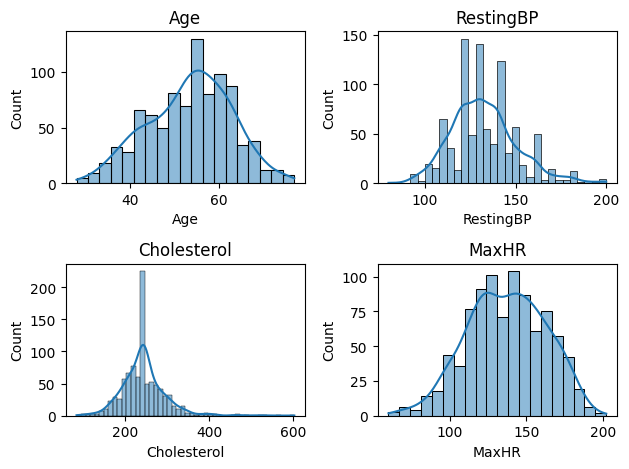

In [338]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df_cleaned[var],kde=True)
  plt.title(var)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

<Axes: xlabel='HeartDisease', ylabel='Age'>

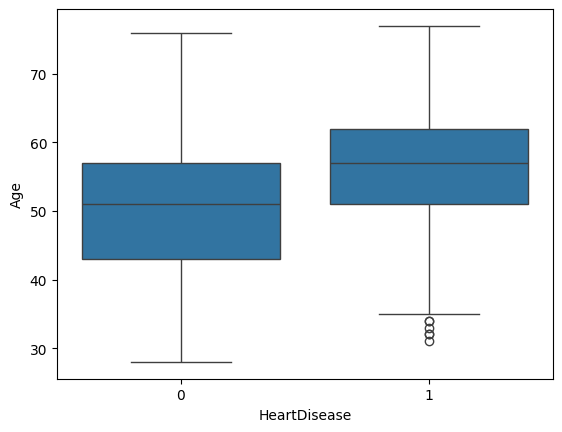

In [339]:
sns.boxplot(x='HeartDisease',y='Age',data=df_cleaned)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

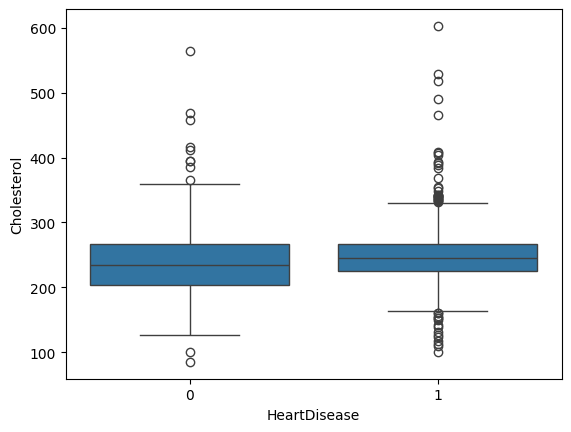

In [340]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df_cleaned)

<Axes: xlabel='HeartDisease', ylabel='MaxHR'>

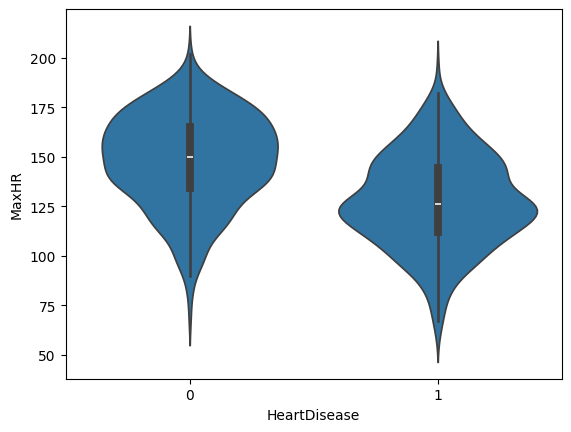

In [341]:
sns.violinplot(x='HeartDisease',y='MaxHR',data=df_cleaned)

<Axes: >

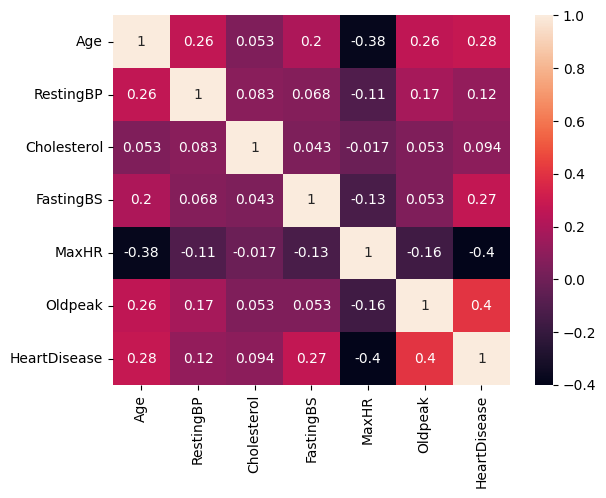

In [342]:
sns.heatmap(df_cleaned.corr(numeric_only=True),annot=True)

In [343]:
df_encode=pd.get_dummies(df_cleaned,drop_first=True)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [344]:
df_encode=df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [345]:
df_encode.shape

(918, 16)

In [346]:
x=df_encode.drop(['HeartDisease'],axis=1)
y=df_encode['HeartDisease']

In [347]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [348]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [349]:
models={
    'LR':LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(max_depth= 5),
    'SVC':SVC(),
    'GaussianNB':GaussianNB()
}

In [350]:
result=[]

In [351]:
for name,model in models.items():
  model.fit(x_train_scaled,y_train)
  y_pred=model.predict(x_test_scaled)
  acc=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  result.append({
      'model':name,
      'accuracy': round(acc,3),
      'f1_score': round(f1,4)})

In [352]:
result

[{'model': 'LR', 'accuracy': 0.87, 'f1_score': 0.8857},
 {'model': 'KNN', 'accuracy': 0.864, 'f1_score': 0.8815},
 {'model': 'DecisionTreeClassifier', 'accuracy': 0.815, 'f1_score': 0.8365},
 {'model': 'SVC', 'accuracy': 0.848, 'f1_score': 0.8679},
 {'model': 'GaussianNB', 'accuracy': 0.853, 'f1_score': 0.8683}]

In [353]:
import joblib
joblib.dump(models['LR'],'LogisticRegression_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']